In [1]:
# Import packages

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.linear_model import LogisticRegression

# This is the classifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance 
from xgboost import plot_importance

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA. 

# Load dataset into a dataframe
### YOUR CODE HERE ###
df0 = pd.read_csv("HR_capstone_dataset.csv")


# Display first few rows of the dataframe
df0.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df0['Department'].unique()

<StringArray>
[      'sales',  'accounting',          'hr',   'technical',     'support',
  'management',          'IT', 'product_mng',   'marketing',       'RandD']
Length: 10, dtype: str

In [4]:
df0.shape

(14999, 10)

In [5]:
df0.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [6]:
df0 = df0.rename(columns={"Department": "department", "Work_accident": "work_accident", "promotion_last_5years": "promotion_last_5_years"})

In [7]:
list(df0)

['satisfaction_level',
 'last_evaluation',
 'number_project',
 'average_montly_hours',
 'time_spend_company',
 'work_accident',
 'left',
 'promotion_last_5_years',
 'department',
 'salary']

In [8]:
duplicates = df0[df0.duplicated()]

In [9]:
duplicates.shape

(3008, 10)

In [10]:
df1 = df0.drop_duplicates()

# Display first few rows of new dataframe as needed
df1.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
5,0.41,0.50,2,153,3,0,1,0,sales,low
6,0.10,0.77,6,247,4,0,1,0,sales,low
7,0.92,0.85,5,259,5,0,1,0,sales,low
8,0.89,1.00,5,224,5,0,1,0,sales,low
9,0.42,0.53,2,142,3,0,1,0,sales,low


<Axes: xlabel='time_spend_company'>

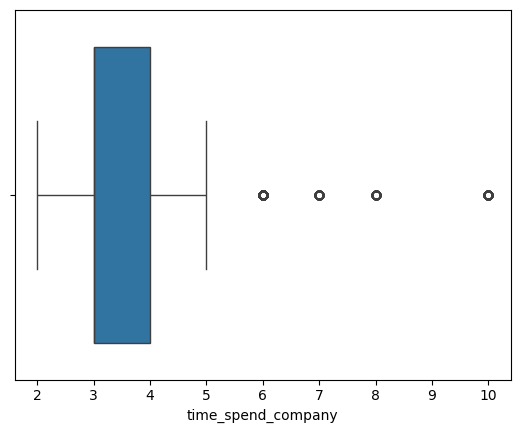

In [11]:
import seaborn as sns
sns.boxplot(x = df1['time_spend_company'])


In [12]:
df1.to_csv('salifort_motors_drop_duplicates.csv') 

In [13]:
Q1 = df1['time_spend_company'].quantile(0.25)
Q3 = df1['time_spend_company'].quantile(0.75)


In [14]:
Q1

np.float64(3.0)

In [15]:
IQR = Q3 - Q1

nedre_graense = Q1 - 1.5 * IQR
oevre_graense = Q3 + 1.5 * IQR

outliers = df1[(df1['time_spend_company'] < nedre_graense) | (df1['time_spend_company'] > oevre_graense)]

antal_outliers = len(outliers)
print(f"Number of outliers: {antal_outliers}")


Number of outliers: 824


In [16]:
df1.shape

(11991, 10)

In [17]:
df1Low = df1[df1['salary'] == 'low']

In [18]:
df1Low.shape

(5740, 10)

In [19]:
df1Medium = df1[df1['salary'] == 'medium']

In [20]:
df1Medium.shape

(5261, 10)

In [21]:
df1High = df1[df1['salary'] == 'high']

In [22]:
df1High.shape

(990, 10)

<Axes: xlabel='satisfaction_level'>

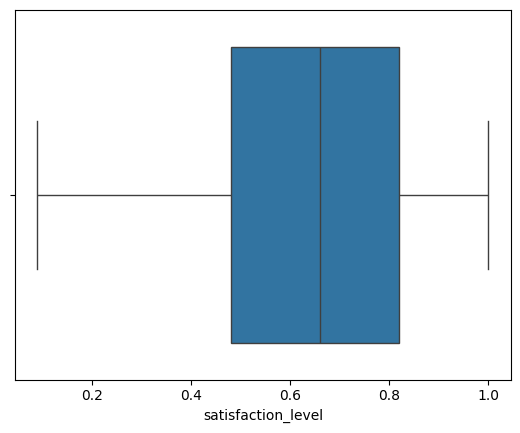

In [23]:
sns.boxplot(x = df1['satisfaction_level'])

<Axes: xlabel='last_evaluation'>

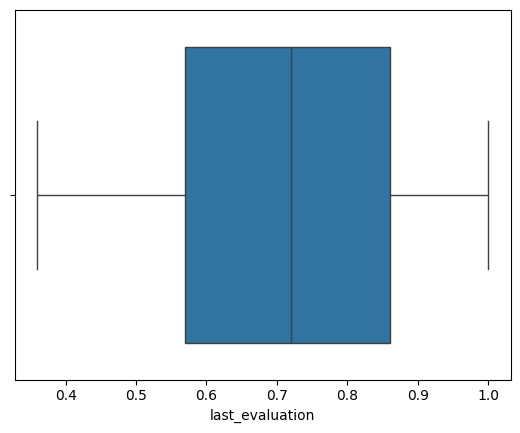

In [24]:
sns.boxplot(x = df1['last_evaluation'])

<Axes: xlabel='average_montly_hours'>

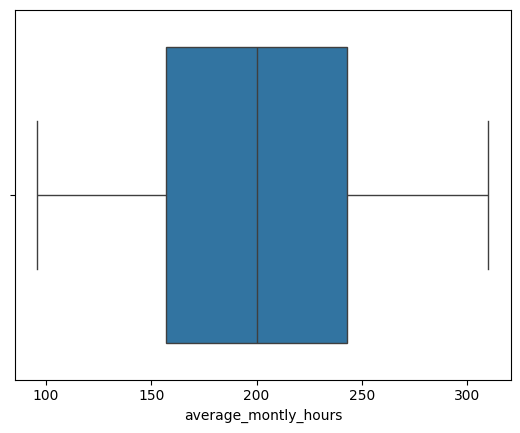

In [25]:
sns.boxplot(x = df1['average_montly_hours'])

<Axes: xlabel='time_spend_company'>

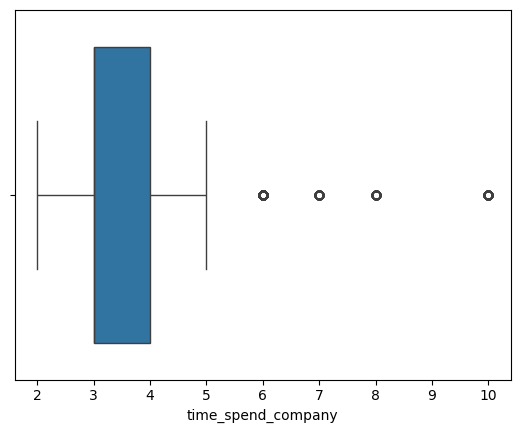

In [26]:
sns.boxplot(x = df1['time_spend_company'])

In [27]:
Q1 = df1['number_project'].quantile(0.25)
Q3 = df1['number_project'].quantile(0.75)

IQR = Q3 - Q1

nedre_graense = Q1 - 1.5 * IQR
oevre_graense = Q3 + 1.5 * IQR

outliers = df1[(df1['number_project'] < nedre_graense) | (df1['number_project'] > oevre_graense)]

antal_outliers = len(outliers)
print(f"Number of outliers: {antal_outliers}")

Number of outliers: 0


In [28]:
#df1Left = df1[df1['left'] == '1']
df1.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      11991 non-null  float64
 1   last_evaluation         11991 non-null  float64
 2   number_project          11991 non-null  int64  
 3   average_montly_hours    11991 non-null  int64  
 4   time_spend_company      11991 non-null  int64  
 5   work_accident           11991 non-null  int64  
 6   left                    11991 non-null  int64  
 7   promotion_last_5_years  11991 non-null  int64  
 8   department              11991 non-null  str    
 9   salary                  11991 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.0 MB


In [29]:
df1Left = df1[df1['left'] == 1]

In [30]:
df1Left.shape[0]

1991

In [31]:
df1stayed = df1[df1['left'] == 0]

In [32]:
df1stayed.shape[0]

10000

In [33]:
df1.shape[0]

11991

In [34]:
round(100/(df1.shape[0]/df1Left.shape[0]),2)

16.6

In [35]:
mapping = {"low": 1, "medium": 2, "high": 3}
df1['salary_category'] = df0['salary'].map(mapping)

In [36]:
df1.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary,salary_category
0,0.38,0.53,2,157,3,0,1,0,sales,low,1
1,0.80,0.86,5,262,6,0,1,0,sales,medium,2
2,0.11,0.88,7,272,4,0,1,0,sales,medium,2
3,0.72,0.87,5,223,5,0,1,0,sales,low,1
4,0.37,0.52,2,159,3,0,1,0,sales,low,1
5,0.41,0.50,2,153,3,0,1,0,sales,low,1
6,0.10,0.77,6,247,4,0,1,0,sales,low,1
7,0.92,0.85,5,259,5,0,1,0,sales,low,1
8,0.89,1.00,5,224,5,0,1,0,sales,low,1
9,0.42,0.53,2,142,3,0,1,0,sales,low,1


In [37]:
mapping = {"sales": 1, "accounting": 2, "hr": 3, "technical":4, "support":5, "management":6, "IT":7, "product_mng":8, "marketing":9, "RandD":10}
df1['department_category'] = df0['department'].map(mapping)

In [38]:
df1.head(10)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary,salary_category,department_category
0,0.38,0.53,2,157,3,0,1,0,sales,low,1,1
1,0.80,0.86,5,262,6,0,1,0,sales,medium,2,1
2,0.11,0.88,7,272,4,0,1,0,sales,medium,2,1
3,0.72,0.87,5,223,5,0,1,0,sales,low,1,1
4,0.37,0.52,2,159,3,0,1,0,sales,low,1,1
5,0.41,0.50,2,153,3,0,1,0,sales,low,1,1
6,0.10,0.77,6,247,4,0,1,0,sales,low,1,1
7,0.92,0.85,5,259,5,0,1,0,sales,low,1,1
8,0.89,1.00,5,224,5,0,1,0,sales,low,1,1
9,0.42,0.53,2,142,3,0,1,0,sales,low,1,1


In [39]:
df1_subset = df1.drop(columns=['department','salary'])


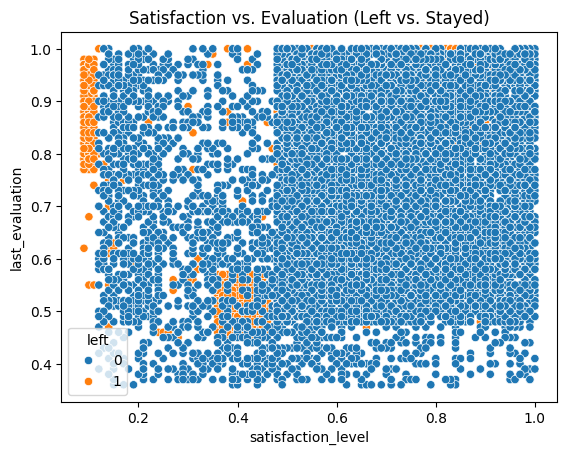

In [40]:
fig = sns.scatterplot(data=df1_subset, x='satisfaction_level', y='last_evaluation', hue='left')
plt.title("Satisfaction vs. Evaluation (Left vs. Stayed)")
plt.show()

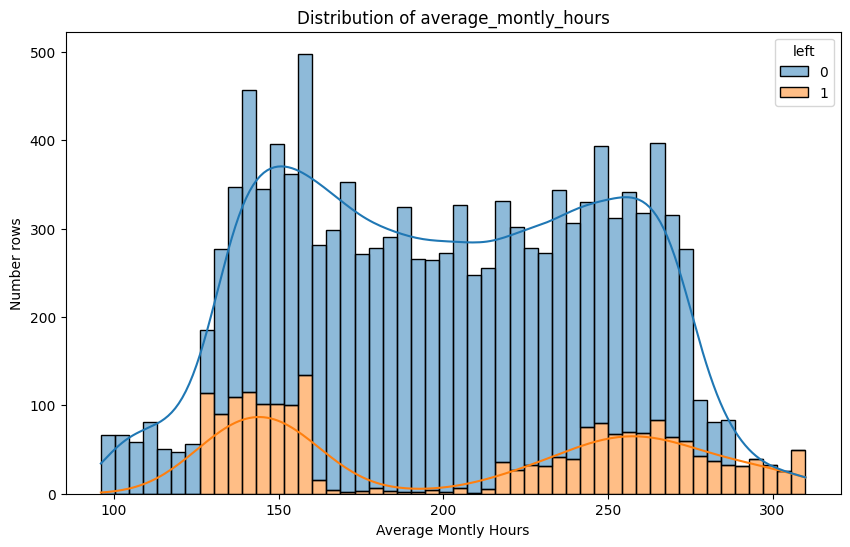

In [41]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df1_subset, x='average_montly_hours', hue='left', kde=True, bins=50, multiple='stack')

plt.xlabel('Average Montly Hours')
plt.ylabel('Number rows')
plt.title('Distribution of average_montly_hours')

plt.show()

Text(0.5, 1.0, 'Distribution of satisfaction_level')

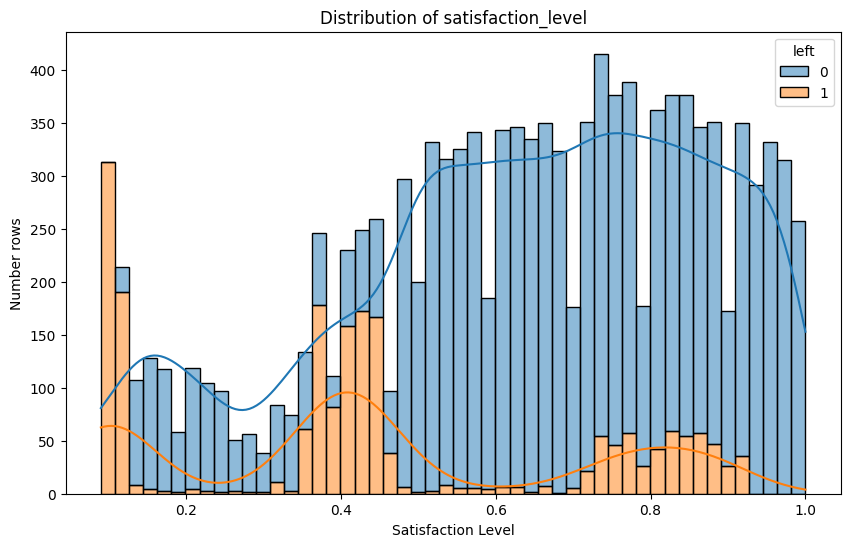

In [42]:
plt.figure(figsize=(10, 6))

sns.histplot(data=df1_subset, x='satisfaction_level', hue='left', kde=True, bins=50, multiple='stack')

plt.xlabel('Satisfaction Level')
plt.ylabel('Number rows')
plt.title('Distribution of satisfaction_level')


In [43]:
dfHeatmap = df1_subset.copy()

In [44]:
dfHeatmap = dfHeatmap.drop(columns=['satisfaction_level','last_evaluation','time_spend_company','work_accident','left','promotion_last_5_years','salary_category','department_category'])
dfHeatmap.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   number_project        11991 non-null  int64
 1   average_montly_hours  11991 non-null  int64
dtypes: int64(2)
memory usage: 281.0 KB


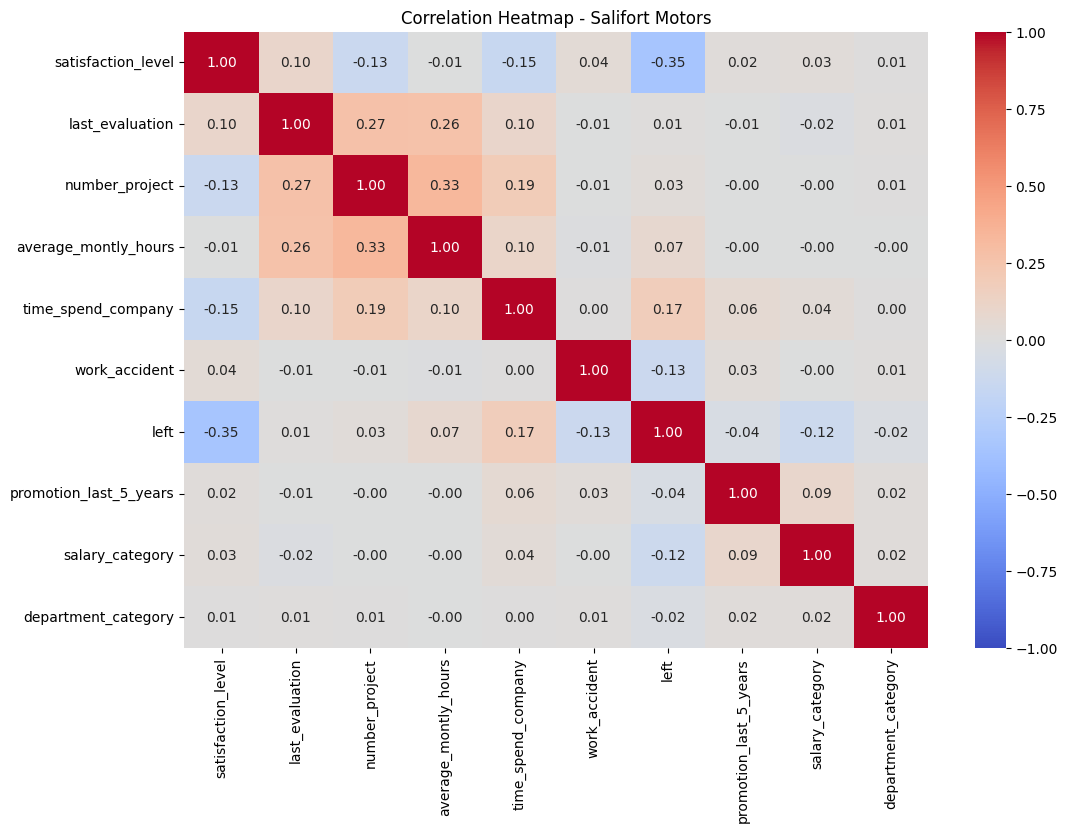

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Beregn korrelationsmatricen
# Vi bruger .select_dtypes(include='number'), da korrelation kun kan beregnes på tal
corr = df1_subset.select_dtypes(include='number').corr()

# 2. Opsæt plottet
plt.figure(figsize=(12, 8))

# 3. Lav selve heatmap'et
sns.heatmap(corr, 
            annot=True,      # Viser tallene (korrelationskoefficienten) i felterne
            cmap='coolwarm', # Farveskala (rød for positiv, blå for negativ korrelation)
            fmt=".2f",       # Formatere tallene til 2 decimaler
            vmin=-1, vmax=1) # Sikrer at farveskalaen altid går fra -1 til 1

# 4. Tilføj titel
plt.title('Correlation Heatmap - Salifort Motors')
plt.show()

In [46]:
df1.to_csv('salifort_motors_drop_duplicates-1.csv') 

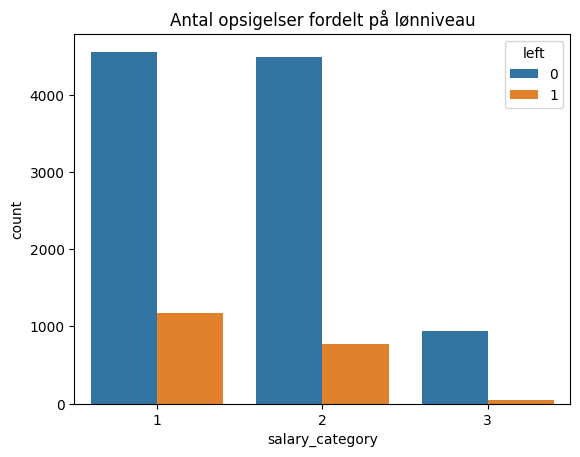

In [47]:
# Prøv dette for at se den virkelige betydning af løn:
sns.countplot(data=df1_subset, x='salary_category', hue='left')
plt.title('Antal opsigelser fordelt på lønniveau')
plt.show()

In [53]:
X = df1[["time_spend_company"]]
y = df1["left"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [55]:
clf = LogisticRegression().fit(X_train,y_train)

In [56]:
clf.coef_

array([[0.29909339]])

In [57]:
clf.intercept_

array([-2.67677387])

<Axes: xlabel='time_spend_company', ylabel='left'>

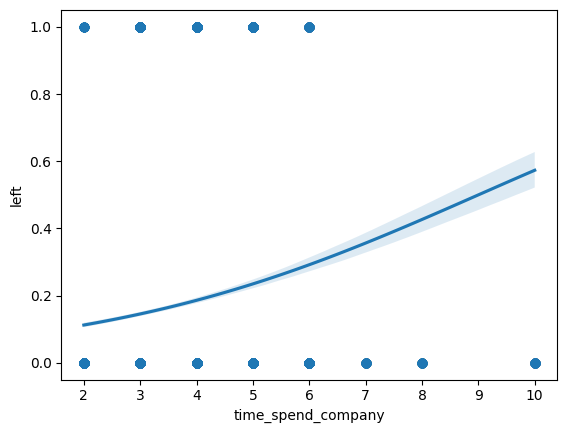

In [58]:
sns.regplot(x="time_spend_company", y="left", data=df1, logistic=True)

In [59]:
# Split data into training and holdout samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build regression model
clf = LogisticRegression().fit(X_train,y_train)

# Save predictions
y_pred = clf.predict(X_test)

In [60]:
# Print out the predicted labels
clf.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(3598,))

In [61]:
# Print out the predicted probabilities
clf.predict_proba(X_test)[::,-1]

array([0.23481729, 0.18536696, 0.11119553, ..., 0.18536696, 0.23481729,
       0.11119553], shape=(3598,))

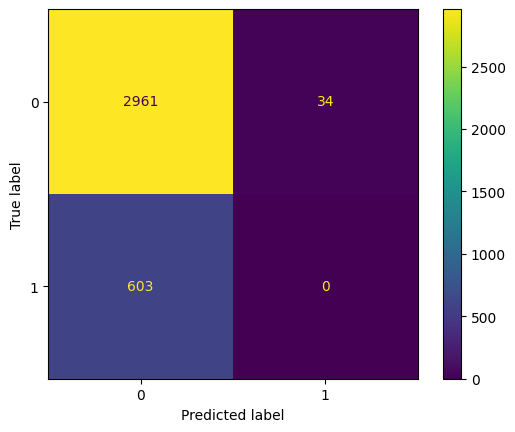

In [62]:
# Import the metrics module from scikit-learn
import sklearn.metrics as metrics
# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)
# Create the confusion matrix as a visualization
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
# Display the confusion matrix
disp.plot()

In [87]:
# Du definerer bare et "array" af dine features
X = df1[['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'work_accident']]
y = df1["left"]


In [88]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

In [89]:
clf = LogisticRegression(max_iter=1000).fit(X_train,y_train)

In [90]:
clf.coef_

array([[-3.86543383,  0.74713935, -0.26204774,  0.00389286,  0.25763441,
        -1.27107202]])

In [91]:
clf.intercept_

array([-0.56987491])

In [92]:
# Split data into training and holdout samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build regression model
clf = LogisticRegression(max_iter=1000).fit(X_train,y_train)

# Save predictions
y_pred = clf.predict(X_test)

In [93]:
clf.coef_

array([[-3.86543383,  0.74713935, -0.26204774,  0.00389286,  0.25763441,
        -1.27107202]])

In [94]:
# Print out the predicted probabilities
clf.predict_proba(X_test)[::,-1]

array([0.62924308, 0.10610166, 0.06393691, ..., 0.0879014 , 0.72144263,
       0.08373241], shape=(3598,))

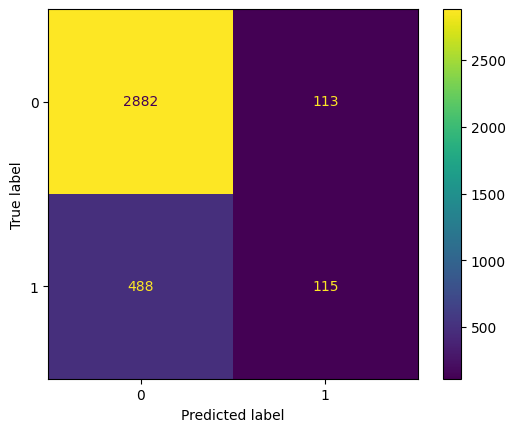

In [95]:
# Import the metrics module from scikit-learn
import sklearn.metrics as metrics
# Calculate the values for each quadrant in the confusion matrix
cm = metrics.confusion_matrix(y_test, y_pred, labels = clf.classes_)
# Create the confusion matrix as a visualization
disp = metrics.ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = clf.classes_)
# Display the confusion matrix
disp.plot()

In [96]:
df0.shape

(14999, 10)

In [97]:
df0.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      14999 non-null  float64
 1   last_evaluation         14999 non-null  float64
 2   number_project          14999 non-null  int64  
 3   average_montly_hours    14999 non-null  int64  
 4   time_spend_company      14999 non-null  int64  
 5   work_accident           14999 non-null  int64  
 6   left                    14999 non-null  int64  
 7   promotion_last_5_years  14999 non-null  int64  
 8   department              14999 non-null  str    
 9   salary                  14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [98]:
df0.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5_years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [99]:
df0['satisfaction_level'].unique()

array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])

In [100]:
df0['last_evaluation'].unique()

array([0.53, 0.86, 0.88, 0.87, 0.52, 0.5 , 0.77, 0.85, 1.  , 0.54, 0.81,
       0.92, 0.55, 0.56, 0.47, 0.99, 0.51, 0.89, 0.83, 0.95, 0.57, 0.49,
       0.46, 0.62, 0.94, 0.48, 0.8 , 0.74, 0.7 , 0.78, 0.91, 0.93, 0.98,
       0.97, 0.79, 0.59, 0.84, 0.45, 0.96, 0.68, 0.82, 0.9 , 0.71, 0.6 ,
       0.65, 0.58, 0.72, 0.67, 0.75, 0.73, 0.63, 0.61, 0.76, 0.66, 0.69,
       0.37, 0.64, 0.39, 0.41, 0.43, 0.44, 0.36, 0.38, 0.4 , 0.42])

In [101]:
df0['number_project'].unique()

array([2, 5, 7, 6, 4, 3])

In [102]:
df0['average_montly_hours'].unique()

array([157, 262, 272, 223, 159, 153, 247, 259, 224, 142, 135, 305, 234,
       148, 137, 143, 160, 255, 282, 147, 304, 139, 158, 242, 239, 128,
       132, 294, 134, 145, 140, 246, 126, 306, 152, 269, 127, 281, 276,
       182, 273, 307, 309, 225, 226, 308, 244, 286, 161, 264, 277, 275,
       149, 295, 151, 249, 291, 232, 130, 129, 155, 265, 279, 284, 221,
       154, 150, 267, 257, 177, 144, 289, 258, 263, 251, 133, 216, 300,
       138, 260, 183, 250, 292, 283, 245, 256, 278, 240, 136, 301, 243,
       296, 274, 164, 146, 261, 285, 141, 297, 156, 287, 219, 254, 228,
       131, 252, 236, 270, 298, 192, 248, 266, 238, 229, 233, 268, 231,
       253, 302, 271, 290, 235, 293, 241, 218, 199, 180, 195, 237, 227,
       172, 206, 181, 217, 310, 214, 198, 211, 222, 213, 202, 184, 204,
       288, 220, 299, 303, 212, 196, 179, 205, 230, 203, 280, 169, 188,
       178, 175, 166, 163, 168, 165, 189, 162, 215, 193, 176, 191, 174,
       201, 208, 171, 111, 104, 106, 100, 194, 209, 185, 200, 20

In [103]:
df0['time_spend_company'].unique()

array([ 3,  6,  4,  5,  2,  8, 10,  7])

In [118]:
df2 = df0.copy()

In [119]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      14999 non-null  float64
 1   last_evaluation         14999 non-null  float64
 2   number_project          14999 non-null  int64  
 3   average_montly_hours    14999 non-null  int64  
 4   time_spend_company      14999 non-null  int64  
 5   work_accident           14999 non-null  int64  
 6   left                    14999 non-null  int64  
 7   promotion_last_5_years  14999 non-null  int64  
 8   department              14999 non-null  str    
 9   salary                  14999 non-null  str    
dtypes: float64(2), int64(6), str(2)
memory usage: 1.1 MB


In [120]:
mapping = {"low": 1, "medium": 2, "high": 3}
df2['salary_category'] = df0['salary'].map(mapping)

In [121]:
df2_subset = df2.drop(columns=['salary'])

In [122]:
df2_subset = pd.get_dummies(df2_subset, columns=["department"])

In [123]:
df2_subset.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   satisfaction_level      14999 non-null  float64
 1   last_evaluation         14999 non-null  float64
 2   number_project          14999 non-null  int64  
 3   average_montly_hours    14999 non-null  int64  
 4   time_spend_company      14999 non-null  int64  
 5   work_accident           14999 non-null  int64  
 6   left                    14999 non-null  int64  
 7   promotion_last_5_years  14999 non-null  int64  
 8   salary_category         14999 non-null  int64  
 9   department_IT           14999 non-null  bool   
 10  department_RandD        14999 non-null  bool   
 11  department_accounting   14999 non-null  bool   
 12  department_hr           14999 non-null  bool   
 13  department_management   14999 non-null  bool   
 14  department_marketing    14999 non-null  bool   
 

In [124]:
# 1. Definer labels (y) - det er vores 'left' kolonne
y = df2_subset['left']

# 2. Definer features (X) - det er hele datasættet undtagen 'left' kolonnen
X = df2_subset.drop('left', axis=1)

In [125]:
# 1. split: Del op i Train og Test (f.eks. 75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

# 2. split: Del det eksisterende X_train op i et nyt træningssæt og et valideringssæt
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=42)

In [135]:
cv_params = {
    'n_estimators' : [100,200],          # Antal træer i skoven (flere er ofte bedre, men langsommere)
    'max_depth' : [None, 5, 10, 20],        # Hvor dybe træerne må blive (None betyder de vokser frit)
    'min_samples_leaf' : [50, 100],      # Minimum antal observationer i et blad
    'min_samples_split' : [4, 8],        # Minimum antal observationer for at lave et split
    'max_features' : [4]           # Hvor mange kolonner hvert træ må kigge på (standard er kvadratroden)   
}

scoring = {
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

In [136]:
from sklearn.model_selection import GridSearchCV, train_test_split, PredefinedSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score

from sklearn.ensemble import RandomForestClassifier

# Lav en liste af indices: 0 for validering, -1 for træning
split_index = [0 if x in X_val.index else -1 for x in X_train.index]
# Opret det tilpassede split
custom_split = PredefinedSplit(split_index)

In [137]:
# Instantiate model.
rf = RandomForestClassifier(random_state=0)

In [141]:
# 1. Opsæt GridSearchCV
rf_val = GridSearchCV(estimator=rf, 
                      param_grid=cv_params, 
                      scoring=scoring,
                      cv=custom_split, 
                      refit='f1', 
                      n_jobs=-1, 
                      verbose=1)


In [142]:

%%time
# Fit the model.
rf_val.fit(X_train, y_train)

Fitting 1 folds for each of 32 candidates, totalling 32 fits
CPU times: total: 2.3 s
Wall time: 41.8 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': [4], 'min_samples_leaf': [50, 100], 'min_samples_split': [4, 8], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...ape=(11249,)))"
,"verbose verbose: intControls the verbosity: the hi

In [140]:
rf_val.best_params_

{'max_depth': None,
 'max_features': 4,
 'min_samples_leaf': 50,
 'min_samples_split': 4,
 'n_estimators': 100}

In [143]:
cv_params = {
    'n_estimators' : [100, 300],
    'max_depth' : [None, 10, 20],
    'min_samples_leaf' : [1, 5, 10], 
    'min_samples_split' : [2, 5, 10],
    'max_features' : [3, 4, 5],
    'max_samples' : [0.7, 0.9] # Prøv at lade hvert træ se 70% eller 90% af data
}

In [144]:
# 1. Opsæt GridSearchCV
rf_val = GridSearchCV(estimator=rf, 
                      param_grid=cv_params, 
                      scoring=scoring,
                      cv=custom_split, 
                      refit='f1', 
                      n_jobs=-1, 
                      verbose=1)


In [145]:

%%time
# Fit the model.
rf_val.fit(X_train, y_train)

Fitting 1 folds for each of 324 candidates, totalling 324 fits
CPU times: total: 8.48 s
Wall time: 3min 29s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': [3, 4, ...], 'max_samples': [0.7, 0.9], 'min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'f1': 'f1', 'precision': 'precision', 'recall': 'recall'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.","PredefinedSpl...ape=(11249,)))"
,"verbose verbose: intControls the verbosit

In [146]:
rf_val.best_params_

{'max_depth': None,
 'max_features': 4,
 'max_samples': 0.9,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [149]:
best_rf_model = rf_val.best_estimator_

In [150]:
rf_opt = RandomForestClassifier(**rf_val.best_params_, random_state=0)

# 2. Fit modellen på dit træningssæt (X_tr og y_tr)
rf_opt.fit(X_tr, y_tr)

# 3. Lav forudsigelser på dine testdata
y_pred = rf_opt.predict(X_test)

In [151]:
# Fit the model.
rf_opt.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

In [152]:
y_pred = rf_opt.predict(X_test)

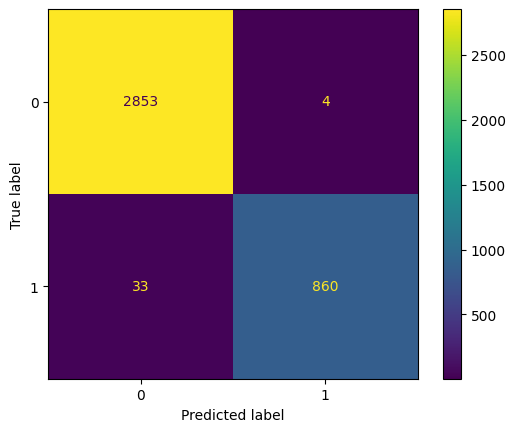

In [153]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=rf_opt.classes_)

In [158]:
from sklearn.metrics import precision_score

# Lav forudsigelser på test-sættet
y_pred = rf_opt.predict(X_test)

# Beregn precision
precision = precision_score(y_test, y_pred, pos_label=1)

print(f"Precision score på test-datasættet: {precision:.4f}")

Precision score på test-datasættet: 0.9954


In [159]:
from sklearn.metrics import recall_score

# Beregn recall på test-sættet
recall = recall_score(y_test, y_pred, pos_label=1)

print(f"Recall score på test-datasættet: {recall:.4f}")

Recall score på test-datasættet: 0.9630


In [160]:
from sklearn.metrics import accuracy_score

# Beregn accuracy på test-sættet
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy score på test-datasættet: {accuracy:.4f}")

Accuracy score på test-datasættet: 0.9901


In [162]:
from sklearn.metrics import f1_score

# Beregn F1 score på test-sættet
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f"F1 score på test-datasættet: {f1:.4f}")

F1 score på test-datasættet: 0.9789


In [164]:
# 1. Opret en dictionary med dine resultater
results_dict = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [0.9901, 0.9954, 0.9630, 0.9789]
}

# 2. Lav det til en DataFrame
df_results = pd.DataFrame(results_dict)

# 3. Vis tabellen
df_results

,Metric,Score
0,Accuracy,0.9901
1,Precision,0.9954
2,Recall,0.9630
3,F1 Score,0.9789
